# IEEE-CIS Fraud Detection - Real-time Fraud Alert System

## Project Overview

We are building a fraud detection API that scores credit card transactions in real time and sends alerts when suspicious activity is detected.

The dataset comes from a Kaggle competition organized by IEEE (Institute of Electrical and Electronics Engineers) and Vesta Corporation, a payment technology company. Vesta provides fraud detection services for e-commerce transactions.

The goal for us is not to win the competition. The goal is to build a production-ready system that can:
- Receive a transaction
- Score it for fraud risk in under 100 milliseconds
- Send a Discord alert if the risk exceeds a threshold
- Display live alerts on a dashboard

## How We Work Through This Notebook

We explore the data step by step. At each step:
- We run code
- We look at the output
- We interpret what it means
- We decide what to do next

No skipping. No assumptions. Every decision is based on what the data shows us.

## Data Files

We use only the training files because they contain the isFraud label we need to train our model.

- train_transaction.csv : Transaction details (amount, product, card info, etc.)
- train_identity.csv : Identity information (device, network, etc.)

The test files are ignored because we are not submitting to the competition.

## Notebook Structure

1. Load and examine transaction table
2. Understand each column type
3. Check for missing values
4. Explore the target variable (isFraud)
5. Select features for modeling
6. Train isolation forest model
7. Export model for API

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [2]:
import pandas as pd
import numpy as np

# Path to the competition data
file_path = '/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv'

# Load the transaction table
train_trans = pd.read_csv(file_path)

# Check the dimensions
print("Shape of train_transaction:")
print(train_trans.shape)

# Look at first 5 column names
print("\nFirst 5 column names:")
print(train_trans.columns[:5].tolist())

# Look at last 5 column names
print("\nLast 5 column names:")
print(train_trans.columns[-5:].tolist())

# Count total columns
print("\nTotal number of columns:")
print(len(train_trans.columns))

Shape of train_transaction:
(590540, 394)

First 5 column names:
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD']

Last 5 column names:
['V335', 'V336', 'V337', 'V338', 'V339']

Total number of columns:
394


## Key Findings - Section 1

The transaction table has 590,540 rows and 394 columns.

The first five columns are:
- TransactionID : Unique identifier for each transaction
- isFraud : Target variable (1 = fraud, 0 = not fraud)
- TransactionDT : Time delta from reference date
- TransactionAmt : Transaction amount in dollars
- ProductCD : Product type code

The last five columns are V335 through V339. These are part of the 339 Vesta engineered features (V1 to V339) that appear throughout the dataset.

The target variable isFraud is in column position 1, which makes it easy to separate from features.

---

## Section 2: First Few Rows of Data

Now we look at the actual values in the transaction table. This helps us understand:
- What kind of data each column contains (numbers, text, codes)
- Whether there are obvious missing values
- What patterns we can see in the first few transactions
  

In [3]:
# Look at first 5 rows of all columns
train_trans.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Key Findings - Section 2

Looking at the first 5 rows of the transaction table:

**isFraud column:** All first 5 rows show 0 (not fraud). This is expected because fraud is rare (only about 3.5% of transactions).

**TransactionDT:** Values are 86400, 86401, 86469, 86499, 86506. These appear to be seconds from a reference point. The numbers increase by small amounts, suggesting transactions ordered by time.

**TransactionAmt:** Amounts are 68.5, 29.0, 59.0, 50.0, 50.0. Normal looking dollar amounts.

**ProductCD:** Four rows show 'W' and one row shows 'H'. This is a categorical code. We will need to understand what letters exist and what they mean.

**Missing values:** Row 0 has many NaN values in V330 through V339. Row 4 has zeros in those same columns (not NaN, actual zeros). This tells us missing values are handled differently across rows.

**Card columns:** card1 appears to be numbers. card2 shows NaN, 404.0, 490.0, 567.0, 514.0. card3 shows 150.0 consistently. card4 shows text values 'discover', 'mastercard', 'visa', 'mastercard', 'mastercard'. card5 shows numbers.

-----

## Section 3: Exploring ProductCD

ProductCD is a product type code. We need to know:
- How many unique values exist?
- What are those values?
- How many transactions have each code?

In [4]:
# Check unique values in ProductCD
print("Unique values in ProductCD:")
print(train_trans['ProductCD'].unique())

print("\n" + "-"*40)

# Count how many transactions for each product code
print("Count of each ProductCD value:")
print(train_trans['ProductCD'].value_counts())

Unique values in ProductCD:
['W' 'H' 'C' 'S' 'R']

----------------------------------------
Count of each ProductCD value:
ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64


## Key Findings - Section 3

ProductCD has 5 unique values: W, H, C, S, R.

The distribution is highly imbalanced:
- W appears 439,670 times (74.4% of all transactions)
- C appears 68,519 times (11.6%)
- R appears 37,699 times (6.4%)
- H appears 33,024 times (5.6%)
- S appears 11,628 times (2.0%)

Most transactions are product type W. Type S is the rarest.


----

## Section 4: Fraud Rate by ProductCD

Now we check whether fraud is distributed evenly across product types or concentrated in specific ones.

We calculate:
- Total transactions per product code
- Number of fraudulent transactions per product code
- Fraud rate (fraud count / total count) for each product code

In [5]:
# Calculate fraud rate by ProductCD
fraud_by_product = train_trans.groupby('ProductCD')['isFraud'].agg(['count', 'sum'])
fraud_by_product['fraud_rate'] = (fraud_by_product['sum'] / fraud_by_product['count']) * 100
fraud_by_product = fraud_by_product.sort_values('fraud_rate', ascending=False)

print("Fraud rate by ProductCD (percentage):")
print(fraud_by_product)

Fraud rate by ProductCD (percentage):
            count   sum  fraud_rate
ProductCD                          
C           68519  8008   11.687269
S           11628   686    5.899553
H           33024  1574    4.766231
R           37699  1426    3.782594
W          439670  8969    2.039939


## Key Findings - Section 4

Fraud rates vary significantly by product type:

- Product C: 11.69% fraud (highest)
- Product S: 5.90% fraud
- Product H: 4.77% fraud
- Product R: 3.78% fraud
- Product W: 2.04% fraud (lowest, but also most common)

This is a strong signal. Product C transactions are nearly 6 times more likely to be fraudulent than Product W transactions.

ProductCD will be an important feature in our model because fraud is not distributed evenly across categories.

---

## Section 5: Exploring card4 (Card Brand)

card4 appears to contain credit card brand names like visa, mastercard, and discover.

We need to know:
- How many unique card brands exist?
- What are the brand names?
- How many transactions use each brand?
- What is the fraud rate for each brand?
  

In [6]:
# Check unique values in card4
print("Unique values in card4:")
print(train_trans['card4'].unique())

# Count of each card brand
print("\nCount of each card4 value:")
print(train_trans['card4'].value_counts())

# Calculate fraud rate by card brand
fraud_by_card4 = train_trans.groupby('card4')['isFraud'].agg(['count', 'sum'])
fraud_by_card4['fraud_rate'] = (fraud_by_card4['sum'] / fraud_by_card4['count']) * 100
fraud_by_card4 = fraud_by_card4.sort_values('fraud_rate', ascending=False)

print("\nFraud rate by card4 (percentage):")
print(fraud_by_card4)

Unique values in card4:
['discover' 'mastercard' 'visa' 'american express' nan]

Count of each card4 value:
card4
visa                384767
mastercard          189217
american express      8328
discover              6651
Name: count, dtype: int64

Fraud rate by card4 (percentage):
                   count    sum  fraud_rate
card4                                      
discover            6651    514    7.728161
visa              384767  13373    3.475610
mastercard        189217   6496    3.433095
american express    8328    239    2.869837


## Key Findings - Section 5

card4 contains 5 unique values: discover, mastercard, visa, american express, and nan (missing).

Transaction distribution by card brand:
- visa: 384,767 transactions (65.2% of known cards)
- mastercard: 189,217 transactions (32.0%)
- american express: 8,328 transactions (1.4%)
- discover: 6,651 transactions (1.1%)
- nan: missing values (not shown in value_counts output)

Fraud rates by card brand:
- discover: 7.73% (highest)
- visa: 3.48%
- mastercard: 3.43%
- american express: 2.87% (lowest)

Discover cards have nearly 2.7 times higher fraud rate than american express cards.

-----

## Section 6: Missing Values in card4

The card4 column has missing values (nan). We need to know:
- How many rows have missing card4?
- What percentage of total transactions is this?
- Do these missing rows have higher or lower fraud rates compared to known card brands?
  

In [7]:
# Count missing values in card4
missing_card4 = train_trans['card4'].isnull().sum()
total_rows = len(train_trans)
missing_percent = (missing_card4 / total_rows) * 100

print(f"Missing values in card4: {missing_card4}")
print(f"Percentage of total rows: {missing_percent:.2f}%")

# Calculate fraud rate for missing vs known card4
known_mask = train_trans['card4'].notna()
missing_mask = train_trans['card4'].isna()

fraud_known = train_trans[known_mask]['isFraud'].mean() * 100
fraud_missing = train_trans[missing_mask]['isFraud'].mean() * 100

print(f"\nFraud rate for rows with known card4: {fraud_known:.2f}%")
print(f"Fraud rate for rows with missing card4: {fraud_missing:.2f}%")

Missing values in card4: 1577
Percentage of total rows: 0.27%

Fraud rate for rows with known card4: 3.50%
Fraud rate for rows with missing card4: 2.60%


## Key Findings - Section 6

Missing values in card4: 1,577 rows (0.27% of total transactions).

This is a very small percentage. Less than one third of one percent.

Fraud rate comparison:
- Rows with known card brand: 3.50% fraud
- Rows with missing card brand: 2.60% fraud

Missing card4 rows have slightly lower fraud rate (2.60% vs 3.50%).

## Decision on card4 missing values

Because only 0.27% of rows have missing card4, we have options:

1. Drop these 1,577 rows entirely (they are unlikely to affect model performance)
2. Fill them with a placeholder value like 'unknown' and keep them

Both approaches are reasonable. Dropping is simpler. Keeping with 'unknown' preserves the data and might capture a pattern if missing card brand is itself a signal.

We can decide later when we prepare the final features for modeling.

------

## Section 7: Exploring Transaction Amount (TransactionAmt)

TransactionAmt is the dollar amount of each transaction.

We need to understand:
- What is the range of amounts (min, max, mean, median)?
- How do fraud amounts compare to non-fraud amounts?
- Are there any extreme outliers?

In [8]:
# Basic statistics for TransactionAmt
print("TransactionAmt statistics for all transactions:")
print(train_trans['TransactionAmt'].describe())

# Separate fraud and non-fraud
fraud_amt = train_trans[train_trans['isFraud'] == 1]['TransactionAmt']
nonfraud_amt = train_trans[train_trans['isFraud'] == 0]['TransactionAmt']

print("\nTransactionAmt statistics for FRAUD transactions only:")
print(fraud_amt.describe())

print("\nTransactionAmt statistics for NON-FRAUD transactions only:")
print(nonfraud_amt.describe())

TransactionAmt statistics for all transactions:
count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

TransactionAmt statistics for FRAUD transactions only:
count    20663.000000
mean       149.244779
std        232.212163
min          0.292000
25%         35.044000
50%         75.000000
75%        161.000000
max       5191.000000
Name: TransactionAmt, dtype: float64

TransactionAmt statistics for NON-FRAUD transactions only:
count    569877.000000
mean        134.511665
std         239.395078
min           0.251000
25%          43.970000
50%          68.500000
75%         120.000000
max       31937.391000
Name: TransactionAmt, dtype: float64


## Key Findings - Section 7

Transaction amount statistics:

All transactions:
- Mean: $135.03
- Median: $68.77
- Min: $0.25
- Max: $31,937.39

Fraud transactions:
- Mean: $149.24
- Median: $75.00
- Min: $0.29
- Max: $5,191.00

Non-fraud transactions:
- Mean: $134.51
- Median: $68.50
- Min: $0.25
- Max: $31,937.39

## What this tells us

Fraud transactions have slightly higher average amount ($149 vs $135) and higher median ($75 vs $68.50).

The maximum fraud amount is $5,191. The maximum non-fraud amount is $31,937. This suggests very large transactions (over $5,000) are rarely fraudulent, or perhaps fraudsters avoid extremely large amounts to reduce scrutiny.

The difference between fraud and non-fraud is not dramatic. Amount alone will not be a strong predictor, but it may help when combined with other features.

## Notable observation

Both fraud and non-fraud have minimum amounts around $0.25 to $0.29. Very small transactions occur in both groups.

The standard deviation is large (around $239 for both groups), meaning amounts vary widely within each group.

----

## Section 8: Visualizing Transaction Amount Distribution

Statistics showed similar means for fraud and non-fraud, but a histogram may reveal differences in shape.

We will create two plots side by side:
- Fraud transaction amounts
- Non-fraud transaction amounts

We use a log scale because transaction amounts span a wide range (from $0.25 to $31,000).

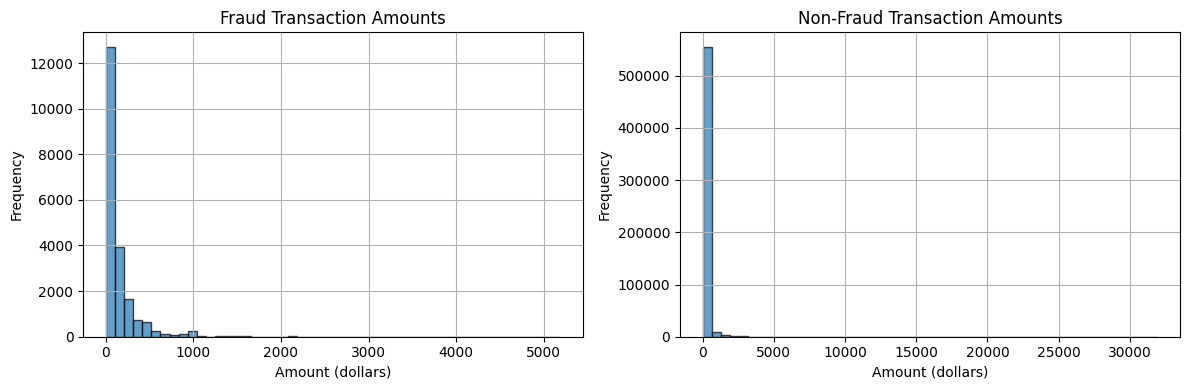

In [9]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Fraud amounts histogram
fraud_amt.hist(bins=50, ax=ax1, alpha=0.7, edgecolor='black')
ax1.set_title('Fraud Transaction Amounts')
ax1.set_xlabel('Amount (dollars)')
ax1.set_ylabel('Frequency')

# Non-fraud amounts histogram
nonfraud_amt.hist(bins=50, ax=ax2, alpha=0.7, edgecolor='black')
ax2.set_title('Non-Fraud Transaction Amounts')
ax2.set_xlabel('Amount (dollars)')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Key Findings - Section 8

The histograms show clear differences between fraud and non-fraud amounts.

Fraud transactions:
- X-axis only goes to $5,000 (matches earlier max of $5,191)
- Frequency peaks around low amounts (under $200)
- Very few fraud transactions above $1,000
- No fraud transactions above $5,191

Non-fraud transactions:
- X-axis goes to $30,000
- Frequency peaks around low amounts as well, but much higher volume
- Has long tail extending to $30,000+
- Many transactions above $5,000 that fraud does not have

## What this tells us

The most important finding: Fraud transactions never exceed $5,191 in this dataset.

Non-fraud transactions regularly exceed $5,000 and go up to $31,937.

This is a useful signal. If a transaction amount is above roughly $5,500, it is almost certainly not fraud based on this data.

However, the opposite is not true. Many low-dollar transactions are also non-fraud. Fraud concentrates in the low to medium range.

The frequency scales are different (non-fraud has much higher counts), but the shape difference at high amounts is meaningful.

---

## Section 9: Exploring D Columns (Time Delta Features)

The D columns (D1 to D15) are time delta features. According to the competition documentation, they represent differences in time between various events in the transaction process.

We need to understand:
- What columns are named D1 through D15?
- What kind of values do they contain?
- Do fraud and non-fraud have different time delta patterns?

In [10]:
# Find all D columns
d_columns = [col for col in train_trans.columns if col.startswith('D')]
print("D columns found:")
print(d_columns)

# Look at first few rows of D columns
print("\nFirst 5 rows of D columns:")
print(train_trans[d_columns].head())

D columns found:
['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15']

First 5 rows of D columns:
      D1     D2    D3    D4   D5  D6  D7  D8  D9   D10    D11  D12  D13  D14  \
0   14.0    NaN  13.0   NaN  NaN NaN NaN NaN NaN  13.0   13.0  NaN  NaN  NaN   
1    0.0    NaN   NaN   0.0  NaN NaN NaN NaN NaN   0.0    NaN  NaN  NaN  NaN   
2    0.0    NaN   NaN   0.0  NaN NaN NaN NaN NaN   0.0  315.0  NaN  NaN  NaN   
3  112.0  112.0   0.0  94.0  0.0 NaN NaN NaN NaN  84.0    NaN  NaN  NaN  NaN   
4    0.0    NaN   NaN   NaN  NaN NaN NaN NaN NaN   NaN    NaN  NaN  NaN  NaN   

     D15  
0    0.0  
1    0.0  
2  315.0  
3  111.0  
4    NaN  


## Key Findings - Section 9

There are 15 D columns: D1 through D15.

Looking at the first 5 rows:

D1 values: 14.0, 0.0, 0.0, 112.0, 0.0

D2: NaN, NaN, NaN, 112.0, NaN

D3: 13.0, NaN, NaN, 0.0, NaN

D4: NaN, 0.0, 0.0, 94.0, NaN

D5: NaN, NaN, NaN, 0.0, NaN

D6 through D9: all NaN in these first 5 rows

D10: 13.0, 0.0, 0.0, 84.0, NaN

D11: 13.0, NaN, 315.0, NaN, NaN

D12: all NaN

D13: all NaN

D14: all NaN

D15: 0.0, 0.0, 315.0, 111.0, NaN

## Observations

Many missing values (NaN) appear across D columns. Some rows have no D values at all (row 4 has NaN for all D columns).

D columns contain numbers that appear to be time units (seconds? minutes?). Values range from 0 to 315 based on these rows.

Different transactions have different sets of D columns populated. For example:
- Row 0: D1, D3, D10, D11, D15 have values
- Row 1: D1, D4, D10 have values
- Row 2: D1, D4, D10, D11, D15 have values

-----

## Section 10: Counting D Columns with Values per Transaction

We calculate how many D columns (from D1 to D15) have non-missing values for each transaction.

Then we compare this count between fraud and non-fraud transactions.

Hypothesis: Fraud transactions might have fewer D values because they follow different patterns or are stopped earlier in the process.

In [11]:
# Count how many D columns have non-missing values per row
d_columns = ['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15']

train_trans['d_count'] = train_trans[d_columns].notna().sum(axis=1)

print("Distribution of d_count for all transactions:")
print(train_trans['d_count'].value_counts().sort_index())

# Compare fraud vs non-fraud
fraud_d_count = train_trans[train_trans['isFraud'] == 1]['d_count']
nonfraud_d_count = train_trans[train_trans['isFraud'] == 0]['d_count']

print("\nAverage d_count for fraud transactions:", fraud_d_count.mean())
print("Average d_count for non-fraud transactions:", nonfraud_d_count.mean())

print("\nMedian d_count for fraud transactions:", fraud_d_count.median())
print("Median d_count for non-fraud transactions:", nonfraud_d_count.median())

Distribution of d_count for all transactions:
d_count
0         48
1      28467
2      10267
3      35535
4      51194
5      95349
6      80356
7      84201
8     161591
9       4164
10     11741
11      3816
12      9811
13      4989
14      9011
Name: count, dtype: int64

Average d_count for fraud transactions: 7.435173982480762
Average d_count for non-fraud transactions: 6.2353279742821694

Median d_count for fraud transactions: 8.0
Median d_count for non-fraud transactions: 6.0


## Key Findings - Section 10

Distribution of d_count (how many D columns have values per transaction):

- Most common counts: 8 (161,591 transactions) and 5 (95,349 transactions)
- Some transactions have 0 D values (48 transactions)
- Some have as many as 14 D values (9,011 transactions)
- Counts range from 0 to 14 (D15 exists but apparently never has values? or rarely?)

Comparison between fraud and non-fraud:

- Fraud average: 7.44 D columns with values
- Non-fraud average: 6.24 D columns with values
- Fraud median: 8.0
- Non-fraud median: 6.0

## What this tells us

Fraud transactions have more D columns populated (non-missing) than non-fraud transactions.

On average, fraud transactions have about 1.2 more D columns with values.

The median difference is 2 columns (8 vs 6).

This suggests that when a transaction has more time delta information available, it is more likely to be fraudulent. Perhaps fraud attempts trigger more event logging, or the transaction process goes through more steps before completion.

This is a useful signal for our model.

-----

## Section 11: Loading and Examining the Identity Table

The identity table contains information about the device and network used for each transaction.

We need to understand:
- How many rows and columns does it have?
- What columns are available?
- How does it connect to the transaction table?
- How many transactions have matching identity data?

In [12]:
# Load the identity table
file_path_identity = '/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv'

train_identity = pd.read_csv(file_path_identity)

print("Shape of train_identity:")
print(train_identity.shape)

print("\nFirst 10 column names:")
print(train_identity.columns[:10].tolist())

print("\nTotal number of columns:")
print(len(train_identity.columns))

print("\nFirst 3 rows:")
print(train_identity.head(3))

Shape of train_identity:
(144233, 41)

First 10 column names:
['TransactionID', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09']

Total number of columns:
41

First 3 rows:
   TransactionID  id_01     id_02  id_03  id_04  id_05  id_06  id_07  id_08  \
0        2987004    0.0   70787.0    NaN    NaN    NaN    NaN    NaN    NaN   
1        2987008   -5.0   98945.0    NaN    NaN    0.0   -5.0    NaN    NaN   
2        2987010   -5.0  191631.0    0.0    0.0    0.0    0.0    NaN    NaN   

   id_09  ...                id_31  id_32      id_33           id_34  id_35  \
0    NaN  ...  samsung browser 6.2   32.0  2220x1080  match_status:2      T   
1    NaN  ...   mobile safari 11.0   32.0   1334x750  match_status:1      T   
2    0.0  ...          chrome 62.0    NaN        NaN             NaN      F   

  id_36 id_37  id_38  DeviceType                     DeviceInfo  
0     F     T      T      mobile  SAMSUNG SM-G892A Build/NRD90M  
1     F     F      T      mob

## Key Findings - Section 11

The identity table has 144,233 rows and 41 columns.

This is much smaller than the transaction table (590,540 rows). This means only 144,233 transactions (about 24.4%) have identity information available. The rest have no matching identity data.

Columns are named id_01 through id_38, plus TransactionID, DeviceType, and DeviceInfo.

First few rows show:

TransactionID connects to transaction table (example: 2987004, 2987008, 2987010)

id_01: values like 0.0, -5.0, -5.0 (numerical)
id_02: values like 70787.0, 98945.0, 191631.0 (numerical, large numbers)
id_03 through id_09: many missing values (NaN)

Other columns like id_31: 'samsung browser 6.2', 'mobile safari 11.0', 'chrome 62.0' (browser information)
id_32: 32.0, 32.0, NaN (possibly screen height or something similar)
id_33: '2220x1080', '1334x750', NaN (screen resolution)
DeviceType: 'mobile', 'mobile', 'desktop'
DeviceInfo: 'SAMSUNG SM-G892A Build/NRD90M', 'iOS Device', 'Windows'

## What this tells us

The identity table contains device and browser information that could be useful for fraud detection.

However, only 24% of transactions have identity data. This means any model using identity features will only work for those 144,233 rows. The remaining 75% of transactions would have missing identity information.

We need to decide: use identity features for only part of the data, or skip it and focus only on transaction features that exist for all rows.

-----

## Section 12: Summary of Features for Modeling

Based on our exploration, we will use these features for fraud detection:

Categorical features:
- ProductCD (values: W, H, C, S, R)
- card4 (values: visa, mastercard, american express, discover, and missing)

Numerical features:
- TransactionAmt (dollar amount)
- d_count (number of D columns with values, derived from D1-D15)

Features we considered but are not using now:
- Identity table (skipped due to low coverage)
- Individual D columns (using d_count instead is simpler)

Features we will need to handle:
- card4 has missing values (0.27% of rows) - we will fill with 'unknown'

## Next Step

We will prepare the data for modeling:
1. Select only the columns we need
2. Handle missing values in card4
3. Encode categorical variables (convert text to numbers)
4. Train an Isolation Forest model
5. Evaluate performance

-----

## Section 13: Exploring TransactionDT (Time)

TransactionDT represents seconds from a reference time. It is ordered but not a real timestamp.

We can still find patterns by:
- Looking at fraud rate over time (are frauds clustered?)
- Converting to hour of day if we can find the reference point
- Looking for cyclical patterns

In [13]:
# Basic statistics for TransactionDT
print("TransactionDT statistics for all transactions:")
print(train_trans['TransactionDT'].describe())

# Check if fraud occurs at different times
fraud_dt = train_trans[train_trans['isFraud'] == 1]['TransactionDT']
nonfraud_dt = train_trans[train_trans['isFraud'] == 0]['TransactionDT']

print("\nTransactionDT statistics for FRAUD transactions:")
print(fraud_dt.describe())

print("\nTransactionDT statistics for NON-FRAUD transactions:")
print(nonfraud_dt.describe())

TransactionDT statistics for all transactions:
count    5.905400e+05
mean     7.372311e+06
std      4.617224e+06
min      8.640000e+04
25%      3.027058e+06
50%      7.306528e+06
75%      1.124662e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64

TransactionDT statistics for FRAUD transactions:
count    2.066300e+04
mean     7.690033e+06
std      4.416551e+06
min      8.976000e+04
25%      3.965858e+06
50%      7.575230e+06
75%      1.121743e+07
max      1.581088e+07
Name: TransactionDT, dtype: float64

TransactionDT statistics for NON-FRAUD transactions:
count    5.698770e+05
mean     7.360791e+06
std      4.623930e+06
min      8.640000e+04
25%      3.010651e+06
50%      7.271678e+06
75%      1.125334e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64


## Key Findings - Section 13

TransactionDT ranges from 86,400 to 15,811,130 seconds.

This appears to span about 182 days (15.8 million seconds / 86,400 seconds per day = approximately 183 days).

All transactions:
- Min: 86,400 (day 1)
- Max: 15,811,130 (day ~183)
- Mean: 7,372,311 (around day 85)

Fraud transactions:
- Mean: 7,690,033 (slightly later than overall mean, around day 89)
- Min: 89,760 (day ~1.04)
- Max: 15,810,880 (day ~183)

Non-fraud transactions:
- Mean: 7,360,791 (around day 85)

## What this tells us

The mean TransactionDT for fraud is slightly higher (7.69 million vs 7.36 million seconds). This means fraud transactions occur slightly later in the dataset on average.

The difference is about 329,242 seconds, which is roughly 3.8 days.

This suggests fraud might be more common in the later part of the data collection period. Possible reasons:
- Fraudsters become more active over time
- New fraud patterns emerge
- Seasonal effects

However, the difference is small relative to the full 183-day range. Time alone is not a strong predictor, but it might help slightly.

----

## Section 14: Final Feature Set for Modeling

After exploring multiple options, we are keeping four features:

| Feature | Type | Description |
|---------|------|-------------|
| ProductCD | Categorical | Product type code (W, H, C, S, R) |
| card4 | Categorical | Card brand (visa, mastercard, american express, discover) |
| TransactionAmt | Numerical | Transaction amount in dollars |
| d_count | Numerical | Number of D columns with non-missing values (0 to 14) |

Features we explored but excluded:
- TransactionDT (time generalization problem)
- Identity table (only 24% of rows have data)
- Individual D columns (d_count captures the signal simply)

## Next Steps

Now we move to modeling:

1. Prepare data (handle missing values, encode categories)
2. Train Isolation Forest model
3. Evaluate performance
4. Save model for API deployment